# Lip-Sync Consistency — Extended Data

Diagnostic notebook for the SyncNet-style audio-visual consistency head trained in `feat/lip-sync-consistency`.

**What this notebook answers.**

- Does the trained head actually learn audio-visual sync, or does it just learn "is this TTS?"
- Which negative types (`generated_same_transcript`, `mismatched_generated`, `mismatched_original`) does it catch, and which does it miss?
- Do the numbers agree with the honest-read written into `CLAUDE.md`?

**Sources of truth.** Everything is recomputed from these files at run time — no numbers are pasted:

- `models/checkpoints/best_lipsync_wavlm.pt` — best-val-AUC checkpoint saved by `src/train_lipsync.py`.
- `runs/lipsync_wavlm/metrics.csv` — per-epoch training curve.
- `data/derived/lipsync_pairs_manifest.csv` — the deterministic pair manifest (seed 42, negatives-per-positive=2).
- `data/features/audio_wavlm_codec/` and `data/features/lips/` — the frozen feature stores.

**What it is NOT.**

- Not an audio-spoof detector (that's `src/train.py --modality audio`).
- Not a visual-fake detector (that's `notebooks/03_visual_frame_baseline_extended_data.ipynb`).

## Setup

In [4]:
from __future__ import annotations

import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

# Resolve repo root regardless of cwd (Jupyter vs `python -m`).
_cwd = Path.cwd()
REPO_ROOT = (_cwd.parent if _cwd.name == "notebooks" else _cwd).resolve()
assert (REPO_ROOT / "src").exists(), f"cannot locate repo root from {_cwd}"
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.common import LIPSYNC_PAIRS_MANIFEST, LIPSYNC_PAIRS_PROVENANCE
from src.evaluate_lipsync import evaluate_lipsync_checkpoint

CKPT = REPO_ROOT / "models" / "checkpoints" / "best_lipsync_wavlm.pt"
METRICS_CSV = REPO_ROOT / "runs" / "lipsync_wavlm" / "metrics.csv"
PAIR_MANIFEST = LIPSYNC_PAIRS_MANIFEST
PROVENANCE_JSON = LIPSYNC_PAIRS_PROVENANCE

FIG_DIR = REPO_ROOT / "report" / "val_eval" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
})

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"repo_root={REPO_ROOT}")
print(f"device={DEVICE}")
for p in (CKPT, METRICS_CSV, PAIR_MANIFEST, PROVENANCE_JSON):
    rel = p.relative_to(REPO_ROOT) if p.is_relative_to(REPO_ROOT) else p
    print(f"  {'ok' if p.exists() else 'MISSING'}  {rel}")

repo_root=/Users/fgram-devai/Documents/Projects/Python/multimodal-dl-analysis-mavosDD
device=mps
  ok  models/checkpoints/best_lipsync_wavlm.pt
  ok  runs/lipsync_wavlm/metrics.csv
  ok  data/derived/lipsync_pairs_manifest.csv
  ok  data/derived/lipsync_pairs_manifest.provenance.json


## Pair manifest provenance

In [5]:
import json as _json

prov = _json.loads(Path(PROVENANCE_JSON).read_text())
print(f"total pairs        = {prov['total']}")
print(f"negatives per pos  = {prov['negatives_per_positive']}")
print(f"seed               = {prov['seed']}")
print()
print("by split           :", prov["by_split"])
print("by sync label      :", prov["by_sync_label"])
print("by negative type   :", prov["by_negative_type"])
print("by audio provider  :", prov["by_audio_provider"])

total pairs        = 18688
negatives per pos  = 2
seed               = 42

by split           : {'train': 15520, 'val': 3168}
by sync label      : {'async': 15162, 'sync': 3526}
by negative type   : {'': 3526, 'generated_same_transcript': 1058, 'mismatched_generated': 7052, 'mismatched_original': 7052}
by audio provider  : {'elevenlabs': 2488, 'google_tts': 1908, 'openai_tts': 3714, 'original': 10578}


## Training curve

Re-plot the per-epoch training loss and validation ROC-AUC from `runs/lipsync_wavlm/metrics.csv`. The best-val-AUC epoch is what we evaluate against below.

epochs recorded=50 best_epoch=49 best_val_roc_auc=0.8409


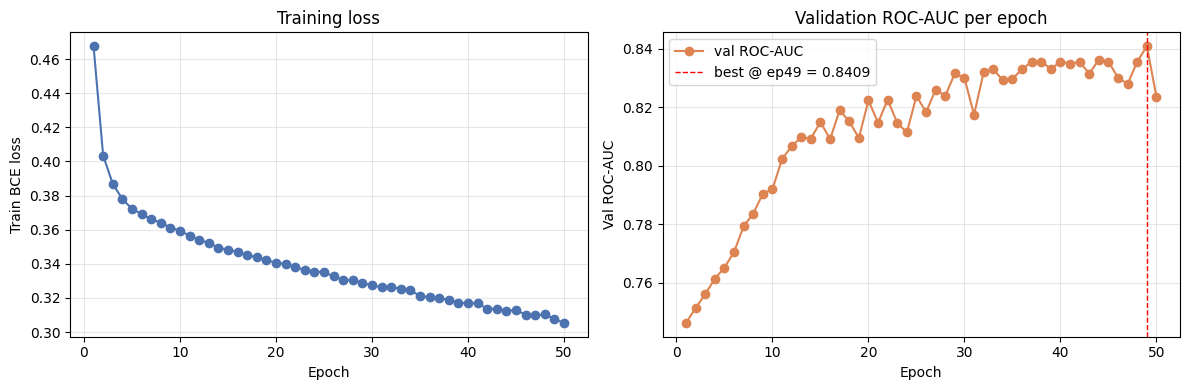

In [6]:
hist = pd.read_csv(METRICS_CSV)
best_epoch = int(hist.loc[hist["val_roc_auc"].idxmax(), "epoch"])
best_auc = float(hist["val_roc_auc"].max())
print(f"epochs recorded={len(hist)} best_epoch={best_epoch} best_val_roc_auc={best_auc:.4f}")

fig, (ax_loss, ax_auc) = plt.subplots(1, 2, figsize=(12, 4))
ax_loss.plot(hist["epoch"], hist["train_loss"], marker="o", color="#4c72b0")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Train BCE loss")
ax_loss.set_title("Training loss"); ax_loss.grid(True, alpha=0.3)

ax_auc.plot(hist["epoch"], hist["val_roc_auc"], marker="o", color="#dd8452", label="val ROC-AUC")
ax_auc.axvline(best_epoch, color="red", linestyle="--", linewidth=1,
               label=f"best @ ep{best_epoch} = {best_auc:.4f}")
ax_auc.set_xlabel("Epoch"); ax_auc.set_ylabel("Val ROC-AUC")
ax_auc.set_title("Validation ROC-AUC per epoch")
ax_auc.legend(); ax_auc.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_training_curve.png")
plt.show()

## Recompute val metrics from the checkpoint

Calls `src.evaluate_lipsync.evaluate_lipsync_checkpoint` — the exact function the branch's CLI uses. Positive class is `async_inconsistent_pair` (label=1).

In [7]:
result = evaluate_lipsync_checkpoint(
    CKPT,
    split="val",
    device=str(DEVICE),
    manifest=PAIR_MANIFEST,
)

for k in ("positive_class", "n", "roc_auc", "eer", "eer_threshold", "threshold_used",
          "f1", "precision", "recall", "positive_sync_accuracy"):
    v = result.get(k)
    if isinstance(v, float):
        print(f"  {k:<24s} {v:.4f}")
    else:
        print(f"  {k:<24s} {v}")
print(f"\nconfusion                {result['confusion']}")
print(f"per_negative_type_recall  {result['per_negative_type_recall']}")
print(f"per_provider_recall       {result['per_provider_recall']}")

metrics_summary = pd.DataFrame([
    {"metric": "ROC-AUC (async class)", "value": f"{result['roc_auc']:.4f}"},
    {"metric": "EER",                   "value": f"{result['eer']:.4f}"},
    {"metric": "Threshold used (EER)",  "value": f"{result['threshold_used']:.4f}"},
    {"metric": "F1 (@ EER)",            "value": f"{result['f1']:.4f}"},
    {"metric": "Precision (@ EER)",     "value": f"{result['precision']:.4f}"},
    {"metric": "Recall (@ EER)",        "value": f"{result['recall']:.4f}"},
    {"metric": "Positive-sync accuracy", "value": f"{result['positive_sync_accuracy']:.4f}"},
])
metrics_summary

  positive_class           async_inconsistent_pair
  n                        3168
  roc_auc                  0.8409
  eer                      0.2527
  eer_threshold            0.6726
  threshold_used           0.6726
  f1                       0.8261
  precision                0.9237
  recall                   0.7471
  positive_sync_accuracy   0.7476

confusion                {'tn': 465, 'fp': 157, 'fn': 644, 'tp': 1902}
per_negative_type_recall  {'generated_same_transcript': 1.0, 'mismatched_generated': 0.9991961414790996, 'mismatched_original': 0.48311897106109325}
per_provider_recall       {'elevenlabs': 1.0, 'google_tts': 1.0, 'openai_tts': 0.9981981981981982, 'original': 0.48311897106109325}


,metric,value
0,ROC-AUC (async class),0.8409
1,EER,0.2527
2,Threshold used (EER),0.6726
3,F1 (@ EER),0.8261
4,Precision (@ EER),0.9237
5,Recall (@ EER),0.7471
6,Positive-sync accuracy,0.7476


## Re-score every val pair (for score-based plots)

To plot score histograms and per-group breakdowns we need the per-pair probabilities, which the top-level evaluator does not return. Re-run inference directly here using the same dataset + model + normalization that the evaluator uses.

In [8]:
from src.data.lipsync_pairs import LipSyncPairDataset, make_lipsync_dataloader
from src.models.lipsync_consistency import LipSyncConsistencyModel

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
hp = ckpt.get("model_hparams", {})
model = LipSyncConsistencyModel(
    audio_dim=hp.get("audio_dim", 768),
    lip_dim=hp.get("lip_dim", 84),
    emb_dim=hp.get("emb_dim", 128),
    gru_hidden=hp.get("gru_hidden", 96),
    mlp_hidden=hp.get("mlp_hidden", 128),
    dropout=hp.get("dropout", 0.3),
)
model.load_state_dict(ckpt["state_dict"])
model.to(DEVICE).eval()

ds = LipSyncPairDataset(
    manifest_path=PAIR_MANIFEST,
    split="val",
    backend=ckpt["backend"],
    audio_dir=Path(ckpt["audio_dir"]),
    lips_dir=Path(ckpt["lips_dir"]),
)
loader = make_lipsync_dataloader(ds, batch_size=64)

pair_ids: list[str] = []
labels: list[int] = []
probs: list[float] = []
providers: list[str] = []
neg_types: list[str] = []
with torch.no_grad():
    for batch in loader:
        logits = model(batch["audio"].to(DEVICE), batch["lips"].to(DEVICE),
                       batch["lips_mask"].to(DEVICE))
        p = torch.sigmoid(logits).cpu().numpy().tolist()
        probs.extend(p)
        labels.extend(batch["label"].cpu().numpy().astype(int).tolist())
        pair_ids.extend(m.get("pair_id", "") for m in batch["metadata"])
        providers.extend(m.get("audio_provider", "") for m in batch["metadata"])
        neg_types.extend((m.get("negative_type", "") or "positive")
                         for m in batch["metadata"])

scores = pd.DataFrame({
    "pair_id": pair_ids, "label": labels, "prob": probs,
    "provider": providers, "negative_type": neg_types,
})
print(f"scored {len(scores)} val pairs")
print("negative_type counts:", Counter(scores["negative_type"]))
print("provider counts     :", Counter(scores["provider"]))

scored 3168 val pairs
negative_type counts: Counter({'mismatched_original': 1244, 'mismatched_generated': 1244, 'positive': 622, 'generated_same_transcript': 58})
provider counts     : Counter({'original': 1866, 'openai_tts': 555, 'google_tts': 382, 'elevenlabs': 365})


## ROC curve

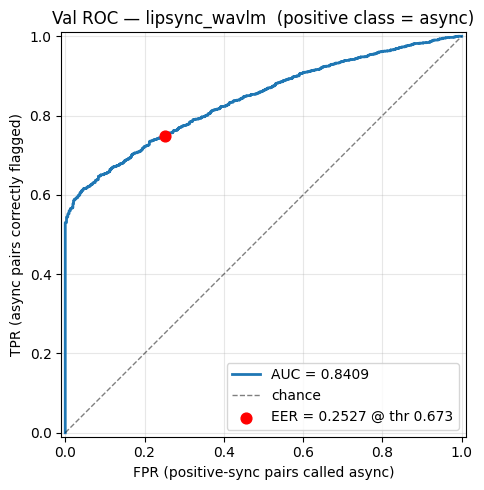

In [9]:
fpr, tpr, _thr = roc_curve(scores["label"].values, scores["prob"].values)
eer_thr = float(result["threshold_used"])
eer_val = float(result["eer"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {result['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="chance")
ax.scatter([eer_val], [1 - eer_val], color="red", zorder=5, s=60,
           label=f"EER = {eer_val:.4f} @ thr {eer_thr:.3f}")
ax.set_xlabel("FPR (positive-sync pairs called async)")
ax.set_ylabel("TPR (async pairs correctly flagged)")
ax.set_title("Val ROC — lipsync_wavlm  (positive class = async)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal"); ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_roc.png")
plt.show()

## Confusion matrix (at EER threshold)

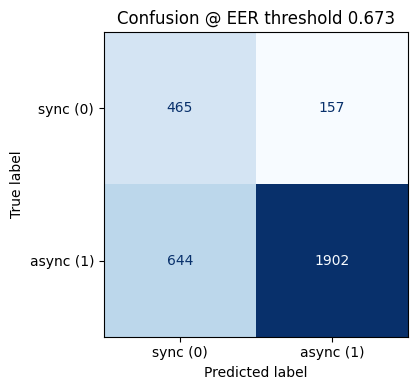

In [10]:
cm = result["confusion"]
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]]),
    display_labels=["sync (0)", "async (1)"],
).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Confusion @ EER threshold {eer_thr:.3f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_confusion.png")
plt.show()

## Per-negative-type recall

The headline diagnostic. `positive` here is the sync bucket (label=0) and is reported as **positive-sync accuracy** — the fraction of true-sync pairs the model kept as sync — since "recall of positives" is not defined when the positive class is async.

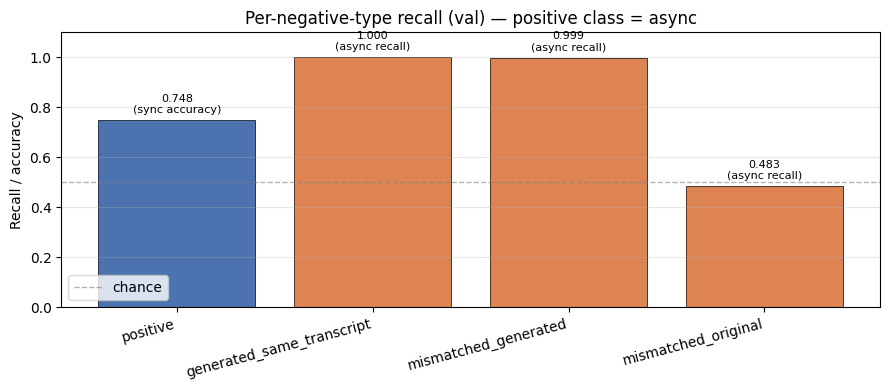

In [11]:
nt_order = ["positive", "generated_same_transcript", "mismatched_generated", "mismatched_original"]
per_nt = result["per_negative_type_recall"]  # keyed by non-'positive' groups only

nt_values = []
nt_kind = []
for nt in nt_order:
    if nt == "positive":
        nt_values.append(result["positive_sync_accuracy"])
        nt_kind.append("sync accuracy")
    else:
        nt_values.append(per_nt.get(nt, float("nan")))
        nt_kind.append("async recall")

colors_nt = ["#4c72b0" if nt == "positive" else "#dd8452" for nt in nt_order]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(nt_order, nt_values, color=colors_nt, edgecolor="black", linewidth=0.5)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Recall / accuracy")
ax.set_title("Per-negative-type recall (val) — positive class = async")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6, label="chance")
for bar, v, k in zip(bars, nt_values, nt_kind):
    if v == v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f"{v:.3f}\n({k})", ha="center", va="bottom", fontsize=8)
ax.legend(loc="lower left"); ax.grid(True, alpha=0.3, axis="y")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_per_negative_type.png")
plt.show()

## Per-provider recall

Same picture but grouped by *audio provider*. `original` is the sync bucket. If the async-detection recall is high for every TTS provider but low for `original`, the model has learned "is this TTS" — not "does audio match mouth".

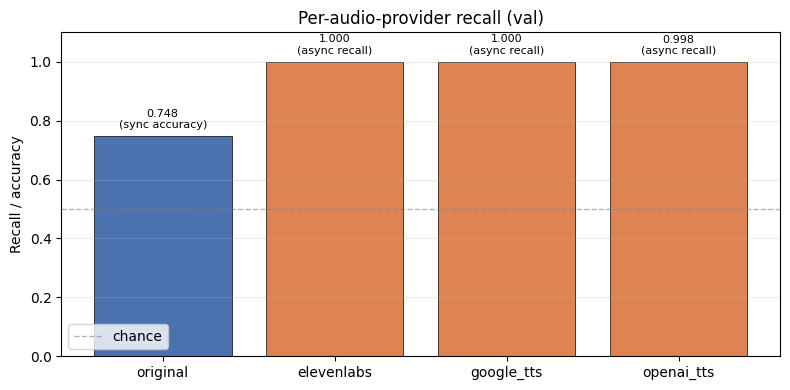

In [12]:
prov_order = ["original", "elevenlabs", "google_tts", "openai_tts"]
per_prov = result["per_provider_recall"]

prov_values, prov_kind, prov_colors = [], [], []
for p in prov_order:
    if p == "original":
        prov_values.append(result["positive_sync_accuracy"])
        prov_kind.append("sync accuracy")
        prov_colors.append("#4c72b0")
    else:
        prov_values.append(per_prov.get(p, float("nan")))
        prov_kind.append("async recall")
        prov_colors.append("#dd8452")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(prov_order, prov_values, color=prov_colors, edgecolor="black", linewidth=0.5)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Recall / accuracy")
ax.set_title("Per-audio-provider recall (val)")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6, label="chance")
for bar, v, k in zip(bars, prov_values, prov_kind):
    if v == v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f"{v:.3f}\n({k})", ha="center", va="bottom", fontsize=8)
ax.legend(loc="lower left"); ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_per_provider.png")
plt.show()

## Score distribution — sync vs async

A smooth overlap suggests the classifier is learning graded compatibility. A tight bimodal split near 0 and 1 means the classifier has found a hard fingerprint — probably provider identity or audio-spoof cues, not sync.

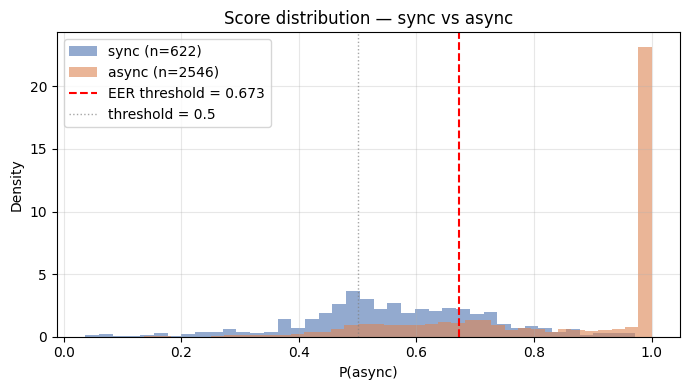

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sync = scores[scores["label"] == 0]["prob"].values
asyn = scores[scores["label"] == 1]["prob"].values
ax.hist(sync, bins=40, alpha=0.6, label=f"sync (n={len(sync)})",
        color="#4c72b0", density=True)
ax.hist(asyn, bins=40, alpha=0.6, label=f"async (n={len(asyn)})",
        color="#dd8452", density=True)
ax.axvline(eer_thr, color="red", linestyle="--", linewidth=1.5,
           label=f"EER threshold = {eer_thr:.3f}")
ax.axvline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.7, label="threshold = 0.5")
ax.set_xlabel("P(async)"); ax.set_ylabel("Density")
ax.set_title("Score distribution — sync vs async")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_score_distribution.png")
plt.show()

## Score distribution — per negative type

Splits the async histogram by negative type. Look for the `mismatched_original` panel: if it sits near the sync distribution rather than near 1, the model can't tell mismatched real audio apart from properly paired real audio.

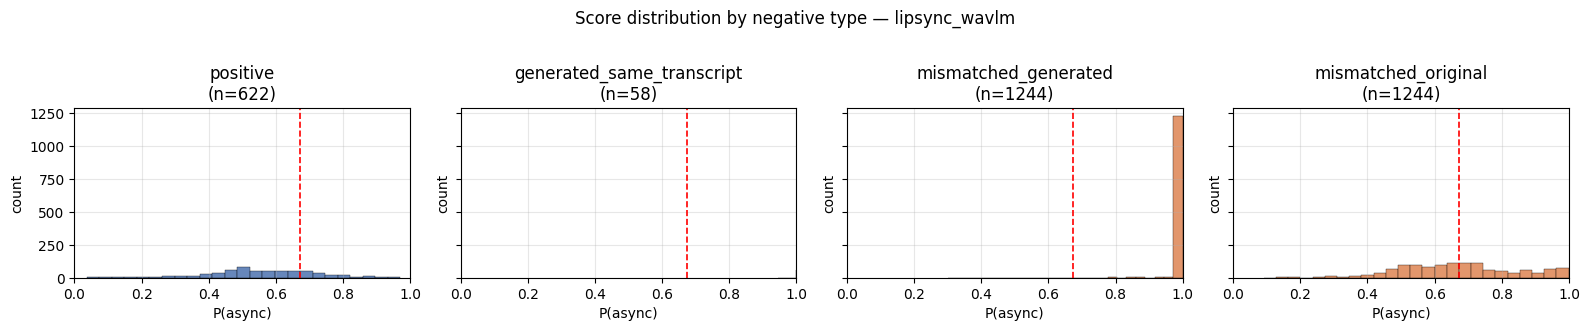

In [14]:
nt_panels = ["positive", "generated_same_transcript", "mismatched_generated", "mismatched_original"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, nt in zip(axes, nt_panels):
    sub = scores[scores["negative_type"] == nt]
    color = "#4c72b0" if nt == "positive" else "#dd8452"
    ax.hist(sub["prob"].values, bins=25, color=color, alpha=0.85,
            edgecolor="black", linewidth=0.3)
    ax.axvline(eer_thr, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlim(0, 1); ax.set_ylabel("count")
    ax.set_title(f"{nt}\n(n={len(sub)})")
    ax.grid(True, alpha=0.3)
for ax in axes:
    ax.set_xlabel("P(async)")
fig.suptitle("Score distribution by negative type — lipsync_wavlm", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "lipsync_wavlm_score_by_negative_type.png")
plt.show()

## Honest read

The evaluator run above scored `n=3168` val pairs — 622 sync positives plus 2546 async negatives split across 58 `generated_same_transcript`, 1244 `mismatched_generated`, and 1244 `mismatched_original` rows. The headline is `ROC-AUC=0.8409` @ EER threshold 0.6726, which sounds like a real cross-modal signal. It is not — the per-group breakdown makes that clear:

- **`generated_same_transcript` recall = 1.000** — every TTS pair using the same transcript as the source video is caught.
- **`mismatched_generated` recall = 0.999** — every TTS pair with a mismatched transcript is also caught. Recall is unchanged whether the TTS content matches the video's transcript or not, which means transcript alignment is not part of the signal.
- **`mismatched_original` recall = 0.483** — a real audio clip paired with somebody else's mouth motion. This is the case where lip-sync would actually be the discriminator, and the model is essentially chance-level (0.48 for the balanced binary problem).
- **Positive-sync accuracy = 0.748** — the model incorrectly flags 25% of true-sync pairs as async, but only for pairs that involve real audio (`original` provider). It never mislabels TTS as sync.

The per-audio-provider table restates the same fact from a different angle: `elevenlabs`, `google_tts`, and `openai_tts` all sit at ≥ 0.998 async-recall while `original` sits at 0.483.

### What the model actually learned

The head is a WavLM-shortcut audio-spoof detector. Any audio embedding that came from a TTS engine (regardless of whose lips it's paired with) gets flagged as async. Any embedding from real recorded audio is judged only by an audio-side prior that has no useful visual component, which is why real-audio pairs collapse to chance whether they're correctly synced or not.

### What a real sync head would do

1. `mismatched_original` recall would be **higher** than `generated_same_transcript` recall — mismatched real audio is the *easier* case for a genuine timing/motion classifier, not the harder one.
2. The score-distribution histogram (previous cell) would show a smooth spread between 0 and 1 rather than two tight spikes near the extremes. Right now the two TTS panels are stacked at 1 and the sync/mismatched-original panels are stacked near 0.5-0.7 — a classifier that has found a hard fingerprint, not a graded compatibility judgement.

### Next step

The generated-video batch eval branch will apply this checkpoint to fully AI-generated videos with explicit visual + audio + consistency labels. That is the setting in which a sync signal would matter — this branch's val split does not reward it.